In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [4]:
df = pd.read_csv('2) Stock Prices Data Set.csv')

In [5]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [6]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [7]:
sample_symbol = df['symbol'].unique()[0]
df_symbol = df[df['symbol'] == sample_symbol].resample('M').mean(numeric_only=True)

/tmp/ipykernel_1485/964950453.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_symbol = df[df['symbol'] == sample_symbol].resample('M').mean(numeric_only=True)


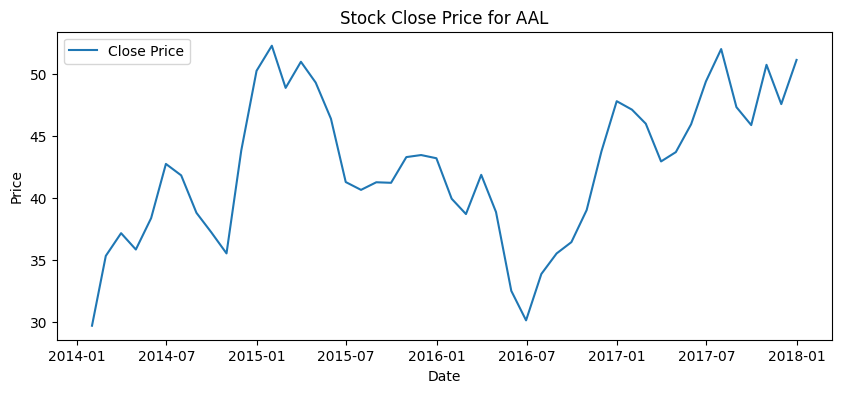

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(df_symbol['close'], label='Close Price')
plt.title(f'Stock Close Price for {sample_symbol}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.savefig('stock_trend.png')
plt.show()

In [9]:
df_symbol['MA_3'] = df_symbol['close'].rolling(window=3).mean()

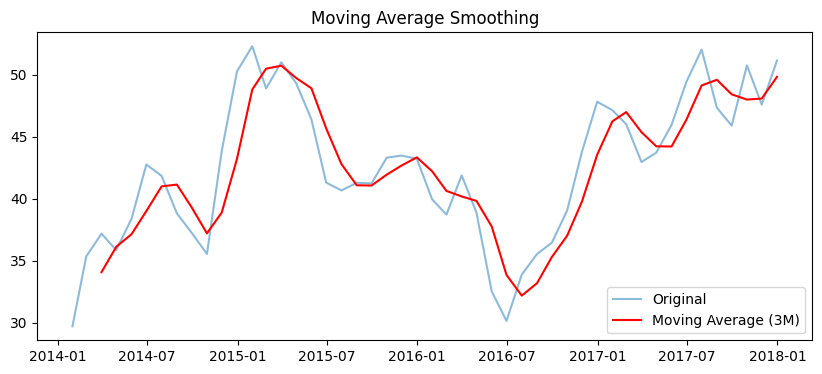

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(df_symbol['close'], label='Original', alpha=0.5)
plt.plot(df_symbol['MA_3'], label='Moving Average (3M)', color='red')
plt.title('Moving Average Smoothing')
plt.legend()
plt.savefig('stock_ma.png')
plt.show()

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [12]:
df_symbol_resampled = df_symbol['close'].resample('D').mean().ffill()

In [15]:
decomposition = seasonal_decompose(df_symbol_resampled, model='additive', period=30)

<Figure size 1200x800 with 0 Axes>

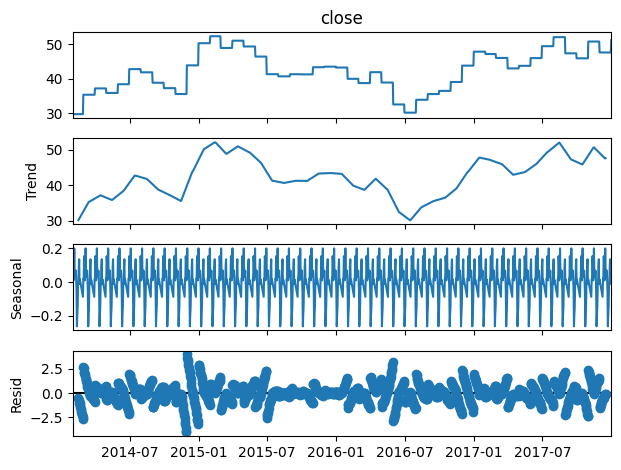

In [16]:
plt.figure(figsize=(12, 8))
decomposition.plot()
plt.savefig('stock_decomposition.png')
plt.show()